## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [94]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

data_dir = '/project/InTEM_GHG/inversion/PARIS_results_sharing/'

model_filenames = {'intem_NIR2024':'InTEM_NAME_EUROPE_NIR2024',
                  'intem_Feb2024':'InTEM_NAME_EUROPE_21Feb2024-D',
                  'intem_fixedbaseline':'InTEM_NAME_EUROPE_Feb2024-fixedbaseline',
                  'rhime':'RHIME_NAME_EUROPE',
                  'elris_fixedbaseline':'ELRIS/ELRIS_NAME_EUROPE_EDGAR_InTEMobs_and_bg_19Feb2024*',
                  'elris':'ELRIS/ELRIS_NAME_EUROPE_EDGAR_11regions_4hourly'}

model_labels = {'intem_NIR2024':'InTEM NIR 2024',
                'intem_Feb2024':'InTEM 4 site',
                'intem_fixedbaseline':'InTEM 4 site\nfixed baseline',
                'rhime':'RHIME',
                'elris_fixedbaseline':'ELRIS fixed\nInTEM baseline and obs',
                'elris':'ELRIS'}

model_colors = {'intem_NIR2024':['darkblue','dodgerblue'],
                'intem_fixedbaseline':['darkblue','dodgerblue'],
                'intem_Feb2024':['darkblue','dodgerblue'],
                'rhime':['darkgreen','green'],
                'elris_fixedbaseline':['purple','mediumpurple'],
                'elris':['purple','mediumpurple']}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [97]:
###################################
### edit variables in this block
species = 'hfc134a'
plot_regions = ['IRELAND','UK','FRANCE','BENELUX','GERMANY','NETHERLANDS'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
models = ['elris_fixedbaseline','intem_fixedbaseline']#'rhime','elris']
start_date = '2018-01-01'
end_date = '2023-01-01'
###################################

ds_all = func.read_flux(data_dir,species,models,model_filenames)

ds_all_scaled = func.slice_flux(ds_all.copy(),start_date,end_date,scale_units=True,
                                species=species)


Attempting to read data from elris_fixedbaseline
Done!

Attempting to read data from intem_fixedbaseline
Done!

Masking data from elris_fixedbaseline
Scaling elris_fixedbaseline units by 1000000.0

Masking data from intem_fixedbaseline
Scaling intem_fixedbaseline units by 1000000.0


#### Then run this to plot:

No inventory data available for BENELUX
ERROR: Either start and end dates are incorrect or there is no BENELUX emissions in elris_fixedbaseline.
Skipping plotting elris_fixedbaseline.
NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


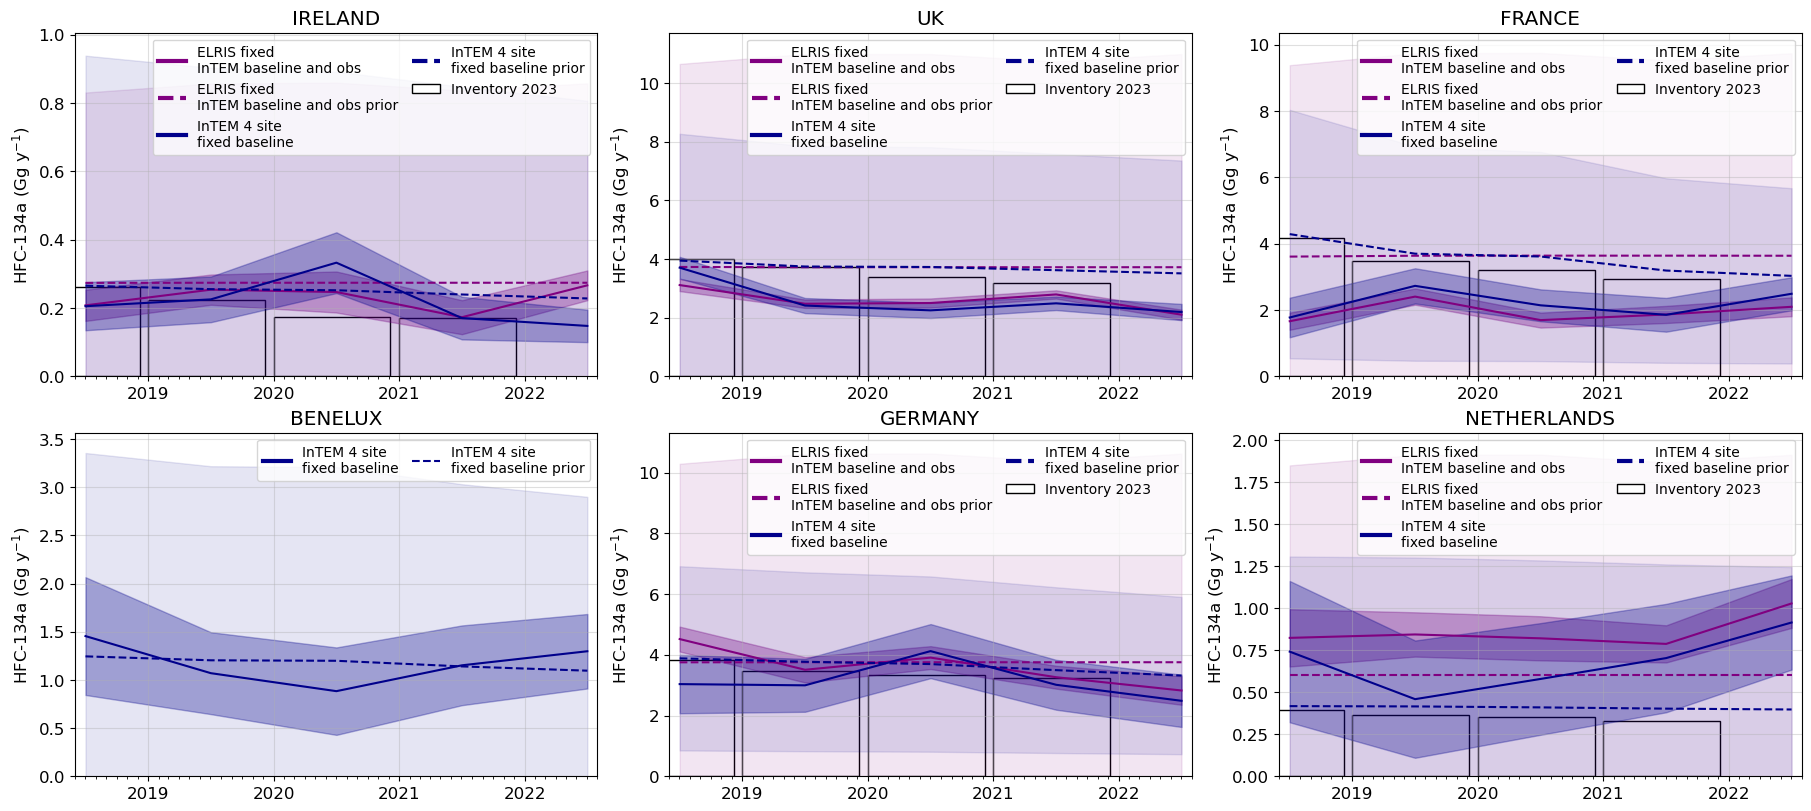

In [100]:
###################################
### edit variables in this block
plot_inventory = True
fix_y_axes = False
###################################

fig = func.plot_country_flux(ds_all_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,data_dir,fix_y_axes)

Save plot here:

In [21]:
#output_path = '/home/h02/aramsden/results/PARIS_results_comparison/fixed_baseline/InTEM_Feb2024_E-D_fixed_baseline_comparison_countryfluxes.png'

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [141]:
###################################
### edit variables in this block
species = 'hfc134a' 
site = 'MHD'
models = ['elris_fixedbaseline','intem_fixedbaseline']#'rhime',]
start_date = '2018-01-01' 
end_date = '2019-01-01'

baseline_site = 'MHD' #can be used to mask the timeseries to only baseline times
baseline_only = True
###################################

ds_all = func.read_mf(data_dir,species,models,model_filenames)

ds_all_sliced = func.slice_mf(ds_all.copy(),start_date,end_date,site,
                              baseline_only=baseline_only,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)


Attempting to read data from elris_fixedbaseline
Done!

Attempting to read data from intem_fixedbaseline
Done!

Masking data from elris_fixedbaseline
Scaling elris_fixedbaseline units by 1e-12
Masking timeseries to only include baseline times

Masking data from intem_fixedbaseline
Scaling intem_fixedbaseline units by 1e-12
Masking timeseries to only include baseline times


#### Create the timeseries plot, separated by model:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


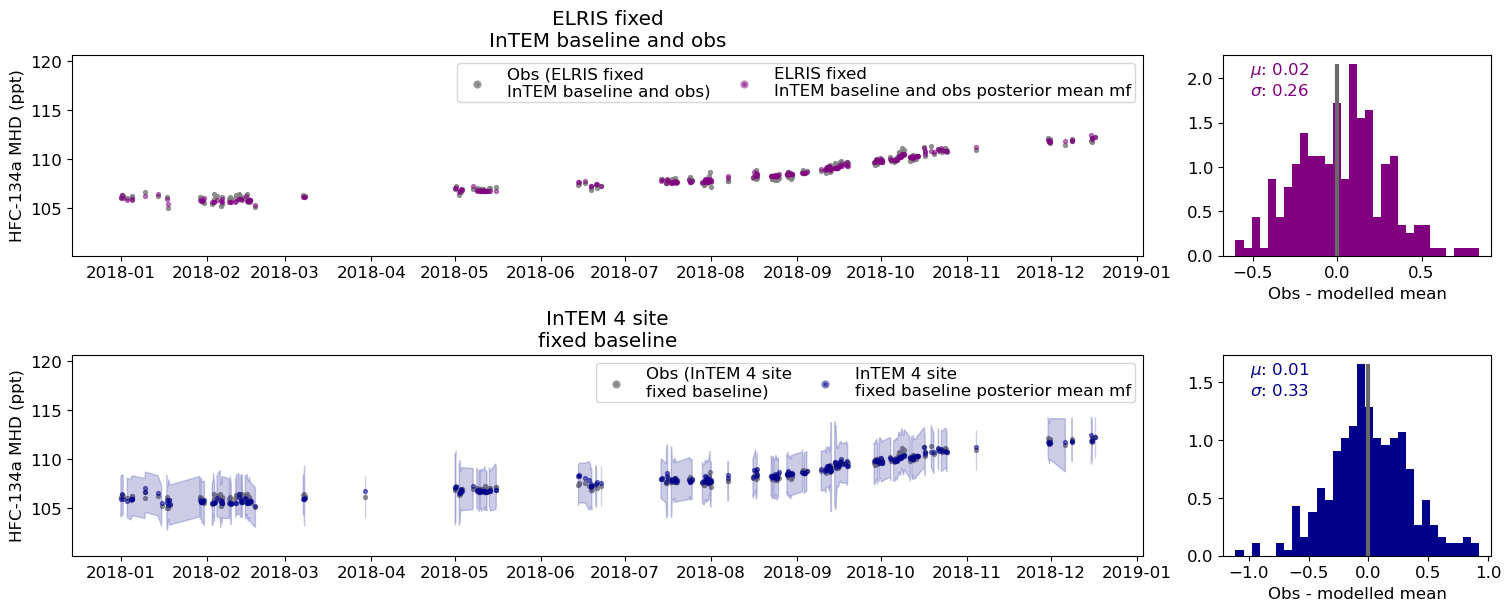

In [143]:
fig = func.plot_obs_modelled_separate(ds_all_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapost'],
                             diff_include=['Yapost'])

#### Create the timeseries plot, all models together:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


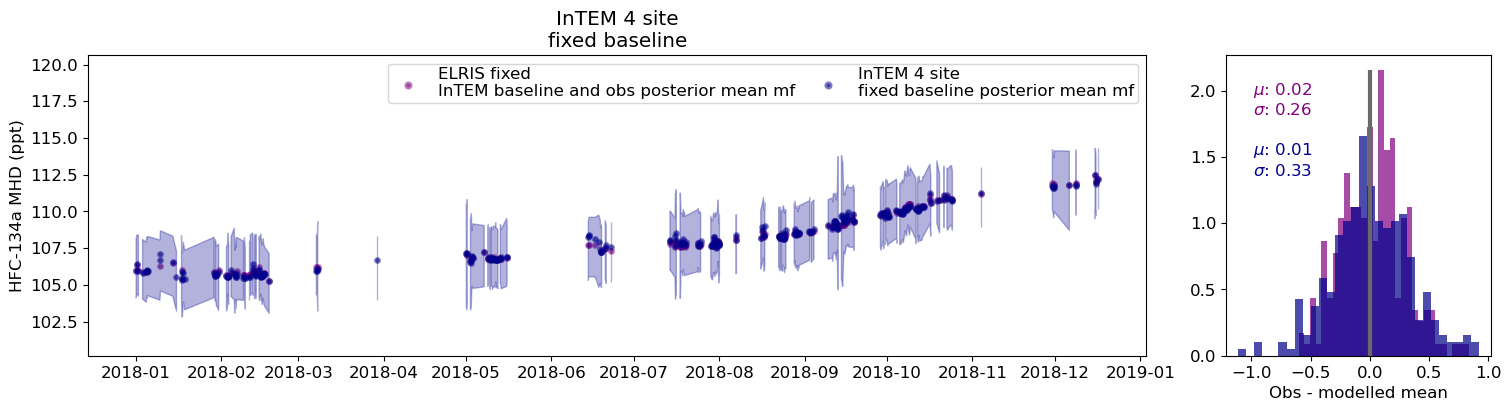

In [145]:
fig = func.plot_obs_modelled_together(ds_all_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'])

#### Plot absolute differences between two models:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


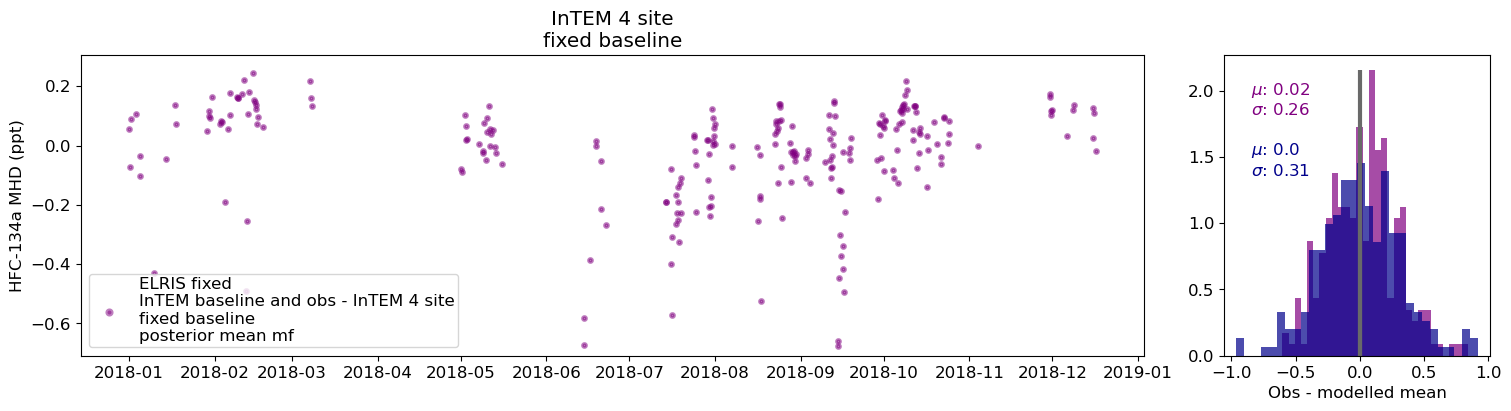

In [147]:
fig = func.plot_obs_diff(ds_all_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'])

#### Calculate and plot stats for the fit to obs:


Masking data from elris_fixedbaseline
Scaling elris_fixedbaseline units by 1e-12
Masking timeseries to only include baseline times

Masking data from intem_fixedbaseline
Scaling intem_fixedbaseline units by 1e-12
Masking timeseries to only include baseline times

Pearson correlation coefficient:
{'CMN': {'elris_fixedbaseline': 0.681, 'intem_fixedbaseline': 0.71},
 'JFJ': {'elris_fixedbaseline': 0.825, 'intem_fixedbaseline': 0.844},
 'MHD': {'elris_fixedbaseline': 0.989, 'intem_fixedbaseline': 0.983},
 'TAC': {'elris_fixedbaseline': 0.76, 'intem_fixedbaseline': 0.742}}

Normalised RMSE
{'CMN': {'elris_fixedbaseline': 0.036, 'intem_fixedbaseline': 0.037},
 'JFJ': {'elris_fixedbaseline': 0.025, 'intem_fixedbaseline': 0.025},
 'MHD': {'elris_fixedbaseline': 0.002, 'intem_fixedbaseline': 0.003},
 'TAC': {'elris_fixedbaseline': 0.046, 'intem_fixedbaseline': 0.051}}


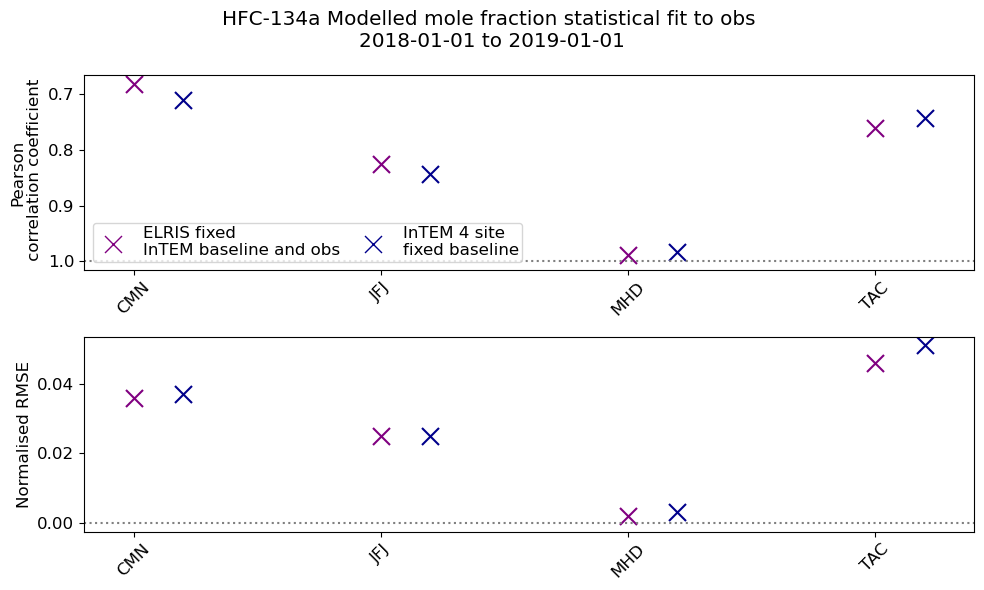

In [149]:
ds_all_allsites = func.slice_mf(ds_all.copy(),start_date,end_date,site=None,
                              baseline_only=baseline_only,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [150]:
###################################
### edit variables in this block
species = 'hfc134a'
start_date = '2018-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2023-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
models = ['intem_NIR2024','elris']#,'rhime','elris_name']
plot_area = 'NWEU' #options for: UK, FRANCE, GERMANY, NWEU, CWEU
###################################

ds_all = func.read_flux(data_dir,species,models,model_filenames)

ds_all_scaled = func.slice_flux(ds_all.copy(),start_date,end_date,scale_units=True,
                                species=species)


Attempting to read data from intem_NIR2024
Done!

Attempting to read data from elris
Done!

Masking data from intem_NIR2024
Scaling intem_NIR2024 units by 1000000.0

Masking data from elris
Scaling elris units by 1000000.0


##### Run this cell to create a plot of prior and posterior fluxes for all models:

Need to fix lat/lon grid in flux plots? InTEM and RHIME country cells don't seem to be aligned?
check in new RHIME output version

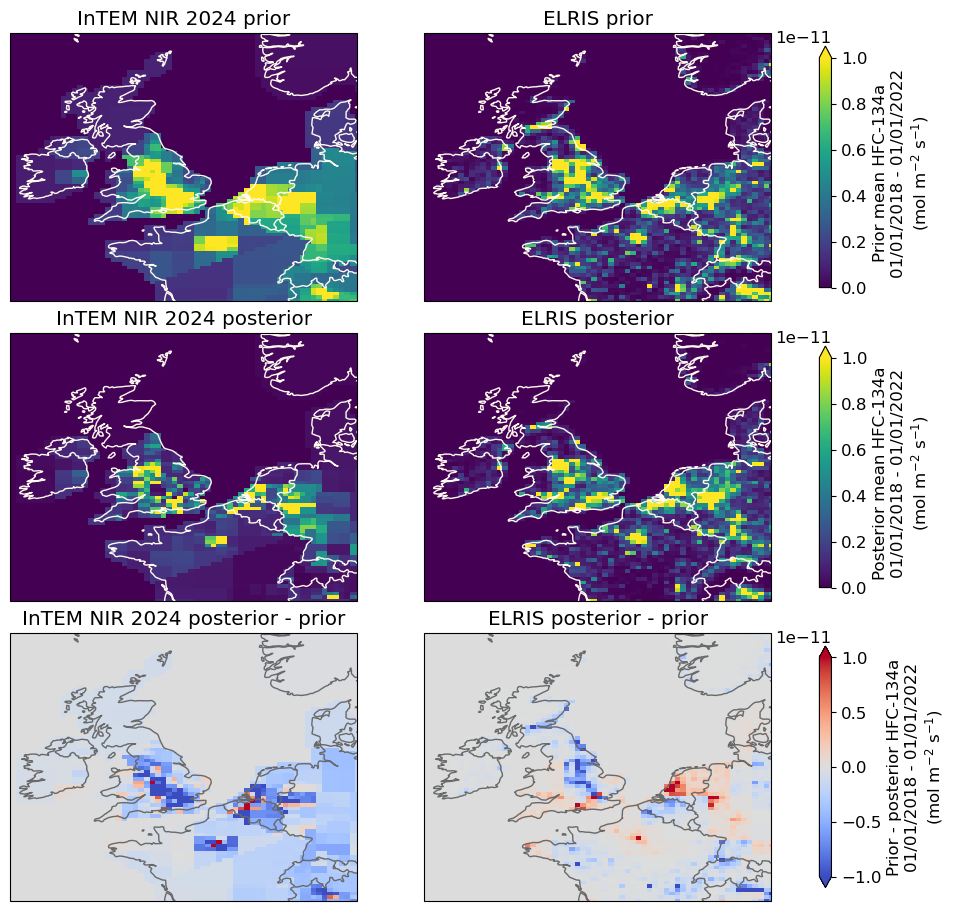

In [160]:
fig = func.plot_spatial_flux(ds_all_scaled,species,plot_area,model_labels)

##### Run this cell to directly compare posterior fluxes from two models:

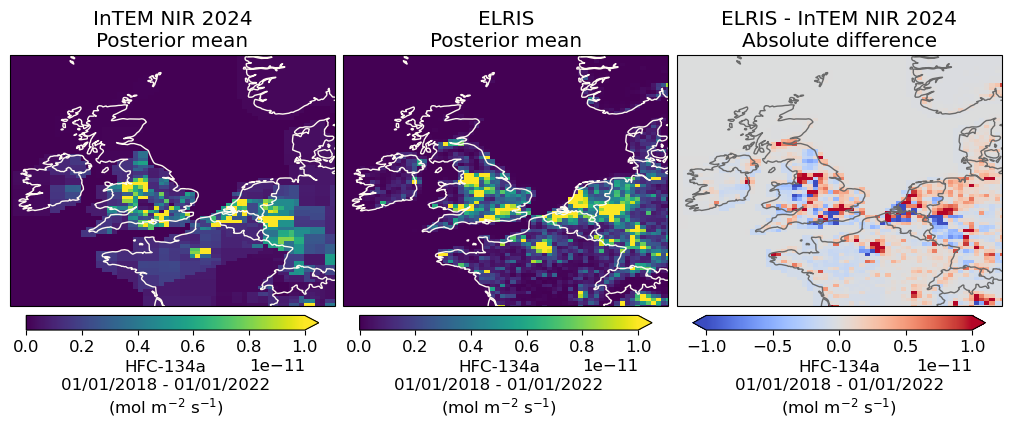

In [153]:
fig = func.plot_spatial_flux_comparison(ds_all_scaled,species,plot_area,model_labels)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')